
# Pharma: Drug Shelf-Life Prediction

## Objective

The objective of this assessment is to analyze a pharmaceutical supply chain dataset and build supervised machine learning models to predict the **Shelf Life (days)** of pharmaceutical products. The project includes data preprocessing, exploratory data analysis, feature engineering, model building, hyperparameter tuning, and model evaluation.

# Task 1: Load and Understand the Dataset

## Objective

The objective of this task is to load the pharmaceutical supply chain dataset into a Pandas DataFrame and understand its structure by examining the columns, data types, shape of the dataset, and identifying the target variable for prediction.

In [1]:
import pandas as pd

In [2]:
# Load the dataset

df = pd.read_csv("Demand Supply Planning.csv")

# Display first five rows

df.head()

,Record_ID,Month,SKU_ID,SKU_Description,Product_Group,UoM,Base_Monthly_Demand,Avg_Monthly_Demand_est,Forecast_Method,Forecast_units,...,Monthly_Revenue_USD,Manufacturing_Line,Production_Capacity_units_per_month,Line_Changeover_time_hrs,Safety_Stock_z90_units,Safety_Stock_z95_units,Safety_Stock_z98_units,OTIF_approx_flag,Capacity_Utilization_pct,Expiry_Value_USD
0,SKU0001_202411,2024-11-01 00:00:00,SKU0001,Surfactants Grade A,Surfactants,kg,571,514,Exponential Smoothing,501,...,"5399,8",Line_A,20000.0,3.0,29,38,47,0,"26,205",0
1,SKU0001_202412,2024-12-01 00:00:00,SKU0001,Surfactants Grade A,Surfactants,kg,571,525,Exponential Smoothing,194,...,"10988,593",Line_A,20000.0,1.0,30,39,48,1,0,0
2,SKU0001_202501,2025-01-01 00:00:00,SKU0001,Surfactants Grade A,Surfactants,kg,571,537,Exponential Smoothing,308,...,"17117,366",Line_A,20000.0,5.0,31,40,49,0,"26,205",0
3,SKU0001_202502,2025-02-01 00:00:00,SKU0001,Surfactants Grade A,Surfactants,kg,571,548,Exponential Smoothing,502,...,"21086,219",Line_A,20000.0,5.0,27,35,43,0,"26,205",0
4,SKU0001_202503,2025-03-01 00:00:00,SKU0001,Surfactants Grade A,Surfactants,kg,571,560,Exponential Smoothing,643,...,"12095,552",Line_A,20000.0,4.0,29,36,45,0,"26,205",0


In [3]:
# Display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 52 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Record_ID                            1000 non-null   object 
 1   Month                                1000 non-null   object 
 2   SKU_ID                               1000 non-null   object 
 3   SKU_Description                      1000 non-null   object 
 4   Product_Group                        1000 non-null   object 
 5   UoM                                  1000 non-null   object 
 6   Base_Monthly_Demand                  1000 non-null   int64  
 7   Avg_Monthly_Demand_est               1000 non-null   int64  
 8   Forecast_Method                      1000 non-null   object 
 9   Forecast_units                       1000 non-null   int64  
 10  Actual_Demand_units                  1000 non-null   int64  
 11  Forecast_Error_units           

In [4]:
# Display the number of rows and columns

print("Shape of Dataset :", df.shape)

Shape of Dataset : (1000, 52)


In [5]:
# Display all column names

print(df.columns.tolist())

['Record_ID', 'Month', 'SKU_ID', 'SKU_Description', 'Product_Group', 'UoM', 'Base_Monthly_Demand', 'Avg_Monthly_Demand_est', 'Forecast_Method', 'Forecast_units', 'Actual_Demand_units', 'Forecast_Error_units', 'Absolute_Error_units', 'APE', 'Supplier_LeadTime_days', 'Transit_days', 'Total_LeadTime_days', 'Safety_Stock_units', 'Reorder_Point_units', 'OnHand_Inventory_units', 'Planned_Receipts_units', 'Replenishment_Order_units', 'Production_Plan_units', 'MOQ_units', 'Unit_Cost_USD', 'Inventory_Value_USD', 'Days_of_Inventory', 'Fill_Rate_pct', 'Stockout_Flag', 'SLOB_Flag', 'Produced_InHouse', 'Shelf_Life_days', 'Manufacturing_Date', 'Expiry_Date', 'Days_to_Expiry', 'Holding_Cost_pct_annual', 'Holding_Cost_USD_monthly', 'Planned_Receipt_Date', 'Actual_Receipt_Date', 'PO_OnTime_Flag', 'Customer_Priority', 'Revenue_per_unit_USD', 'Monthly_Revenue_USD', 'Manufacturing_Line', 'Production_Capacity_units_per_month', 'Line_Changeover_time_hrs', 'Safety_Stock_z90_units', 'Safety_Stock_z95_units', 

In [6]:
# Display data types of all columns

df.dtypes

Record_ID                               object
Month                                   object
SKU_ID                                  object
SKU_Description                         object
Product_Group                           object
UoM                                     object
Base_Monthly_Demand                      int64
Avg_Monthly_Demand_est                   int64
Forecast_Method                         object
Forecast_units                           int64
Actual_Demand_units                      int64
Forecast_Error_units                     int64
Absolute_Error_units                     int64
APE                                     object
Supplier_LeadTime_days                   int64
Transit_days                             int64
Total_LeadTime_days                      int64
Safety_Stock_units                       int64
Reorder_Point_units                      int64
OnHand_Inventory_units                   int64
Planned_Receipts_units                   int64
Replenishment

In [7]:
# Select the target variable

target = "Shelf_Life_days"

print("Target Variable :", target)

Target Variable : Shelf_Life_days


# 2. Handle missing values and outliers.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Check for missing values

df.isnull().sum()

Record_ID                                0
Month                                    0
SKU_ID                                   0
SKU_Description                          0
Product_Group                            0
UoM                                      0
Base_Monthly_Demand                      0
Avg_Monthly_Demand_est                   0
Forecast_Method                          0
Forecast_units                           0
Actual_Demand_units                      0
Forecast_Error_units                     0
Absolute_Error_units                     0
APE                                      0
Supplier_LeadTime_days                   0
Transit_days                             0
Total_LeadTime_days                      0
Safety_Stock_units                       0
Reorder_Point_units                      0
OnHand_Inventory_units                   0
Planned_Receipts_units                   0
Replenishment_Order_units                0
Production_Plan_units                    0
MOQ_units  

In [10]:
# Total missing values

print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 1606


In [11]:
# Fill missing values in numerical columns with median

numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())

In [12]:
# Fill missing values in categorical columns with mode

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [13]:
# Verify missing values after handling

df.isnull().sum()

Record_ID                              0
Month                                  0
SKU_ID                                 0
SKU_Description                        0
Product_Group                          0
UoM                                    0
Base_Monthly_Demand                    0
Avg_Monthly_Demand_est                 0
Forecast_Method                        0
Forecast_units                         0
Actual_Demand_units                    0
Forecast_Error_units                   0
Absolute_Error_units                   0
APE                                    0
Supplier_LeadTime_days                 0
Transit_days                           0
Total_LeadTime_days                    0
Safety_Stock_units                     0
Reorder_Point_units                    0
OnHand_Inventory_units                 0
Planned_Receipts_units                 0
Replenishment_Order_units              0
Production_Plan_units                  0
MOQ_units                              0
Unit_Cost_USD   

In [14]:
# Select all numerical columns

numerical_columns = df.select_dtypes(include=np.number).columns

# Detect outliers using IQR

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(column)
    print("Number of Outliers:", len(outliers))
    print("-" * 40)

Base_Monthly_Demand
Number of Outliers: 30
----------------------------------------
Avg_Monthly_Demand_est
Number of Outliers: 36
----------------------------------------
Forecast_units
Number of Outliers: 39
----------------------------------------
Actual_Demand_units
Number of Outliers: 37
----------------------------------------
Forecast_Error_units
Number of Outliers: 99
----------------------------------------
Absolute_Error_units
Number of Outliers: 70
----------------------------------------
Supplier_LeadTime_days
Number of Outliers: 0
----------------------------------------
Transit_days
Number of Outliers: 4
----------------------------------------
Total_LeadTime_days
Number of Outliers: 0
----------------------------------------
Safety_Stock_units
Number of Outliers: 51
----------------------------------------
Reorder_Point_units
Number of Outliers: 60
----------------------------------------
OnHand_Inventory_units
Number of Outliers: 62
--------------------------------------

ValueError: num must be an integer with 1 <= num <= 20, not 21

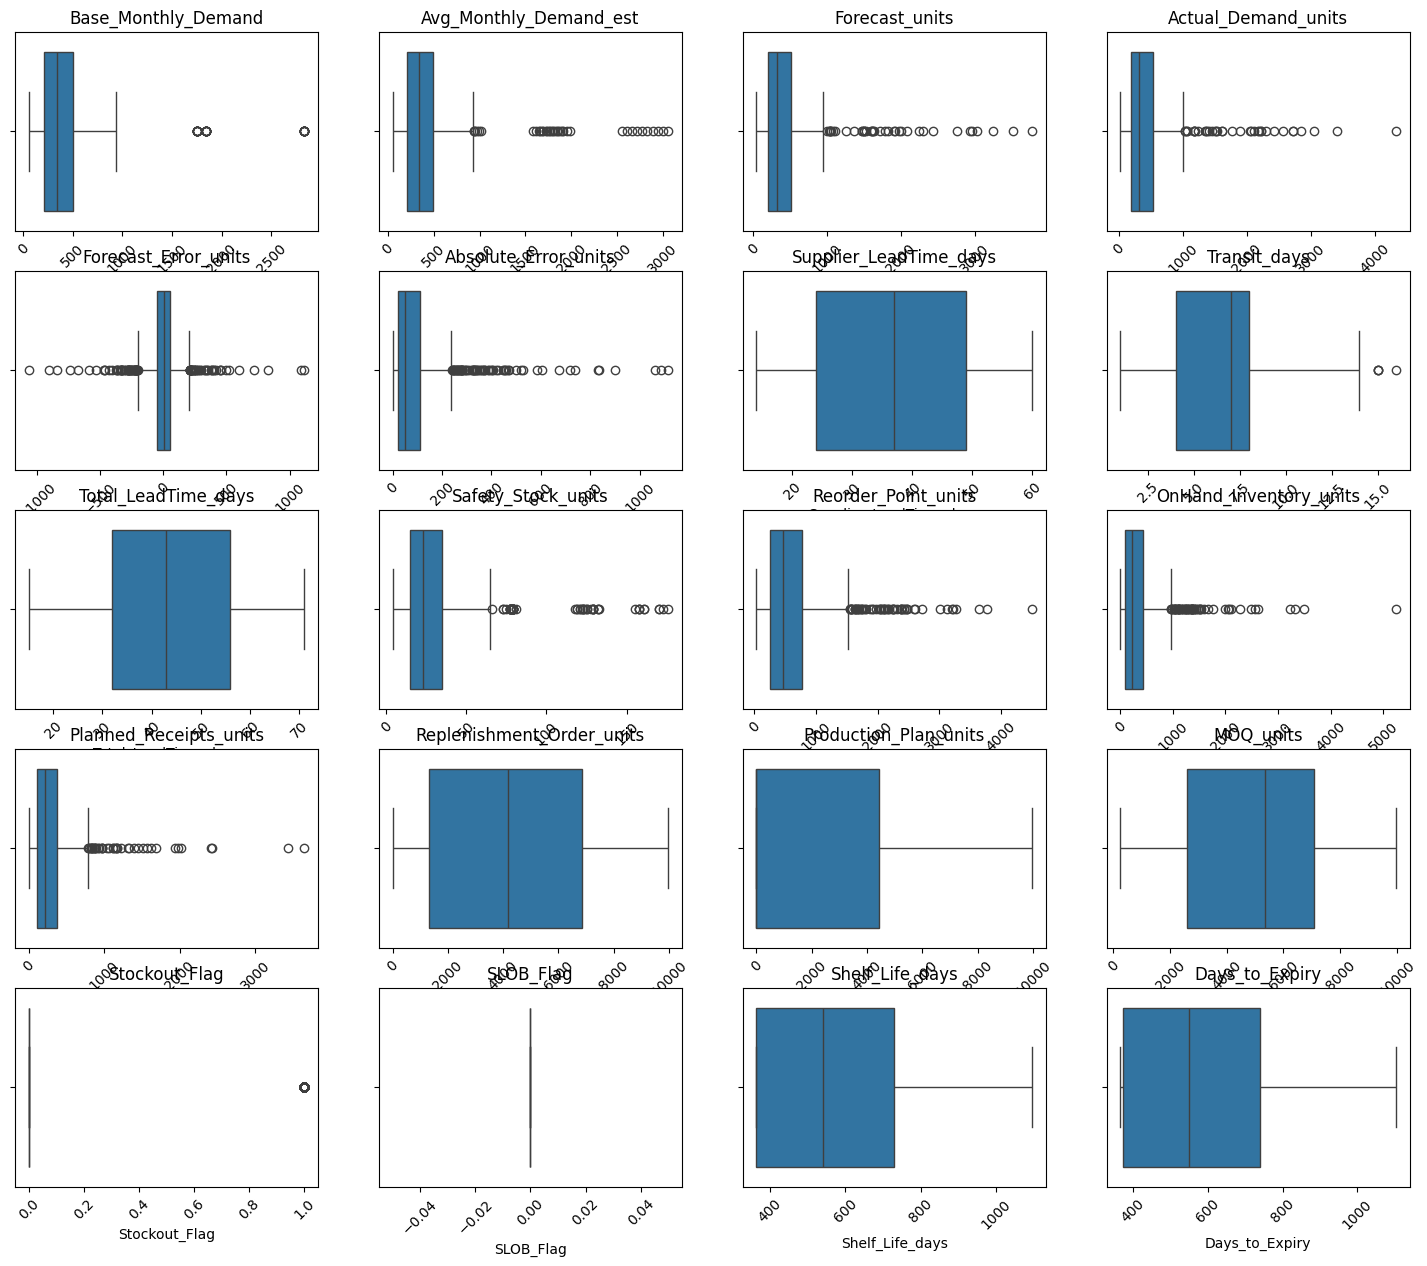

In [15]:
# Boxplots for all numerical columns

plt.figure(figsize=(18, 15))

for i, column in enumerate(numerical_columns, 1):

    plt.subplot(5, 4, i)
    sns.boxplot(x=df[column])
    plt.title(column)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 3. Perform EDA (visualize distributions, correlations).

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

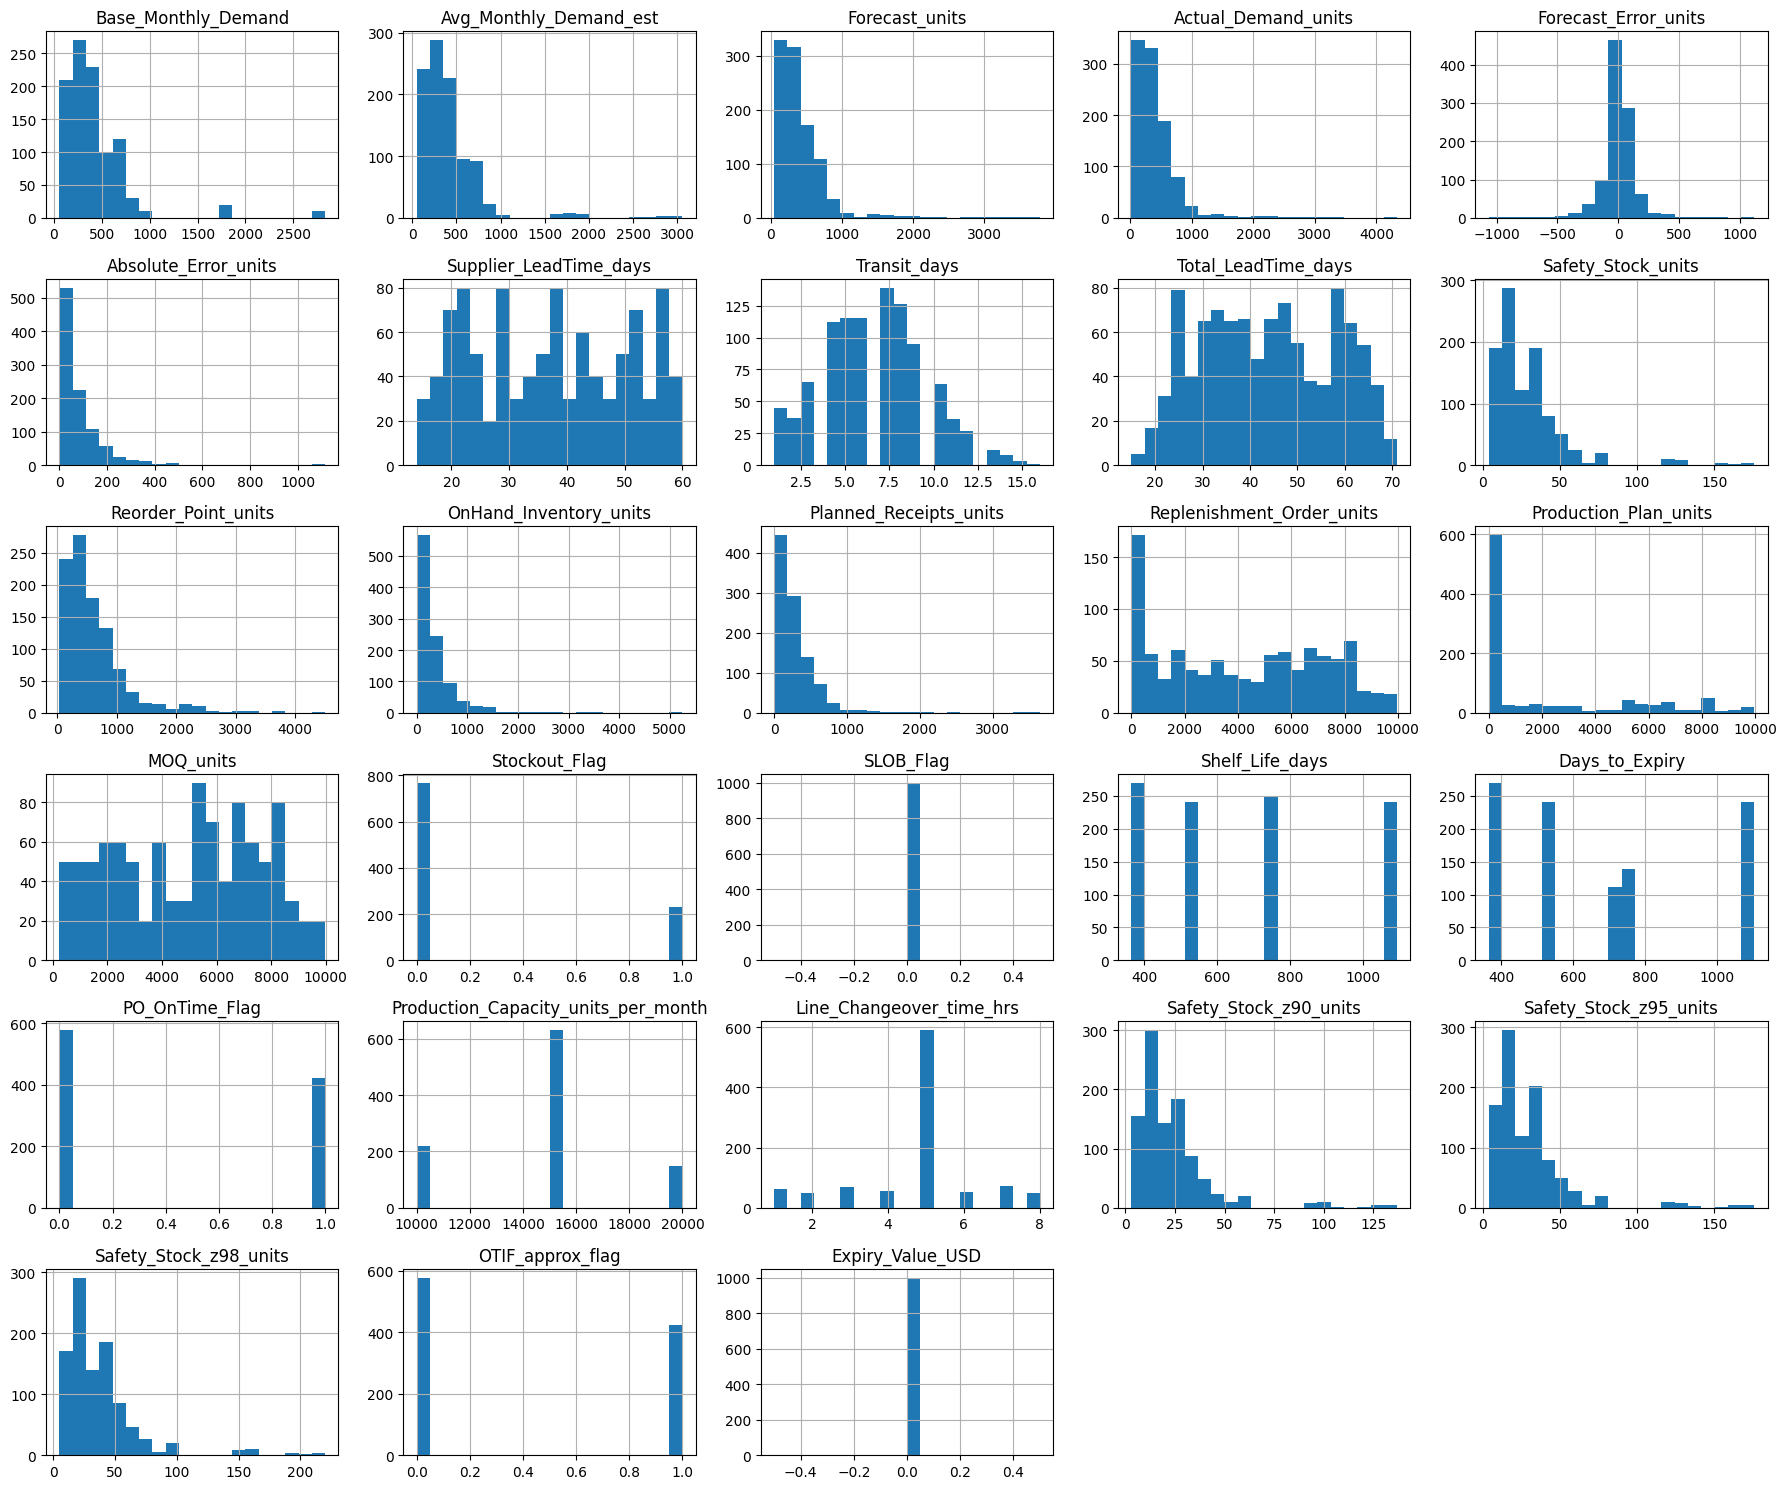

In [ ]:
# Select numerical columns

numerical_columns = df.select_dtypes(include="number").columns

# Plot histograms

df[numerical_columns].hist(figsize=(18, 15), bins=20)

plt.tight_layout()
plt.show()

In [ ]:
# Correlation matrix

correlation = df[numerical_columns].corr()

correlation

,Base_Monthly_Demand,Avg_Monthly_Demand_est,Forecast_units,Actual_Demand_units,Forecast_Error_units,Absolute_Error_units,Supplier_LeadTime_days,Transit_days,Total_LeadTime_days,Safety_Stock_units,...,Shelf_Life_days,Days_to_Expiry,PO_OnTime_Flag,Production_Capacity_units_per_month,Line_Changeover_time_hrs,Safety_Stock_z90_units,Safety_Stock_z95_units,Safety_Stock_z98_units,OTIF_approx_flag,Expiry_Value_USD
Base_Monthly_Demand,1.000000,0.996254,0.970002,0.951354,-0.032018,0.684561,-0.116243,0.026028,-0.107585,0.972617,...,-0.145637,-0.145769,0.001948,0.152352,0.014714,0.972566,0.972649,0.972518,0.001948,NaN
Avg_Monthly_Demand_est,0.996254,1.000000,0.962887,0.944120,-0.032451,0.670045,-0.115814,0.027382,-0.106882,0.968950,...,-0.145099,-0.145214,0.000108,0.151776,0.010659,0.969027,0.969074,0.968945,0.000108,NaN
Forecast_units,0.970002,0.962887,1.000000,0.926489,-0.175034,0.697021,-0.110107,0.018579,-0.103187,0.943400,...,-0.145368,-0.145524,0.004935,0.147917,0.006775,0.943143,0.943387,0.943273,0.004935,NaN
Actual_Demand_units,0.951354,0.944120,0.926489,1.000000,0.208344,0.689261,-0.119377,0.014191,-0.113131,0.922925,...,-0.144788,-0.145055,-0.008237,0.145893,0.009527,0.923114,0.923121,0.922868,-0.008237,NaN
Forecast_Error_units,-0.032018,-0.032451,-0.175034,0.208344,1.000000,-0.008251,-0.026158,-0.011160,-0.027799,-0.037255,...,-0.000995,-0.001287,-0.034376,-0.002739,0.007318,-0.036093,-0.036709,-0.037076,-0.034376,NaN
Absolute_Error_units,0.684561,0.670045,0.697021,0.689261,-0.008251,1.000000,-0.091102,-0.009674,-0.090660,0.653255,...,-0.110343,-0.110890,0.028263,0.113553,0.007831,0.653140,0.653648,0.653388,0.028263,NaN
Supplier_LeadTime_days,-0.116243,-0.115814,-0.110107,-0.119377,-0.026158,-0.091102,1.000000,0.022565,0.977510,0.065121,...,-0.067887,-0.068075,-0.006559,-0.094496,0.020381,0.065703,0.065490,0.065956,-0.006559,NaN
Transit_days,0.026028,0.027382,0.018579,0.014191,-0.011160,-0.009674,0.022565,1.000000,0.232894,0.071349,...,-0.041017,-0.040988,0.003146,-0.017339,-0.014367,0.070125,0.071551,0.071838,0.003146,NaN
Total_LeadTime_days,-0.107585,-0.106882,-0.103187,-0.113131,-0.027799,-0.090660,0.977510,0.232894,1.000000,0.078397,...,-0.074690,-0.074866,-0.005716,-0.095579,0.016795,0.078705,0.078799,0.079312,-0.005716,NaN
Safety_Stock_units,0.972617,0.968950,0.943400,0.922925,-0.037255,0.653255,0.065121,0.071349,0.078397,1.000000,...,-0.139893,-0.140065,-0.004627,0.139228,0.011839,0.999803,0.999813,0.999878,-0.004627,NaN


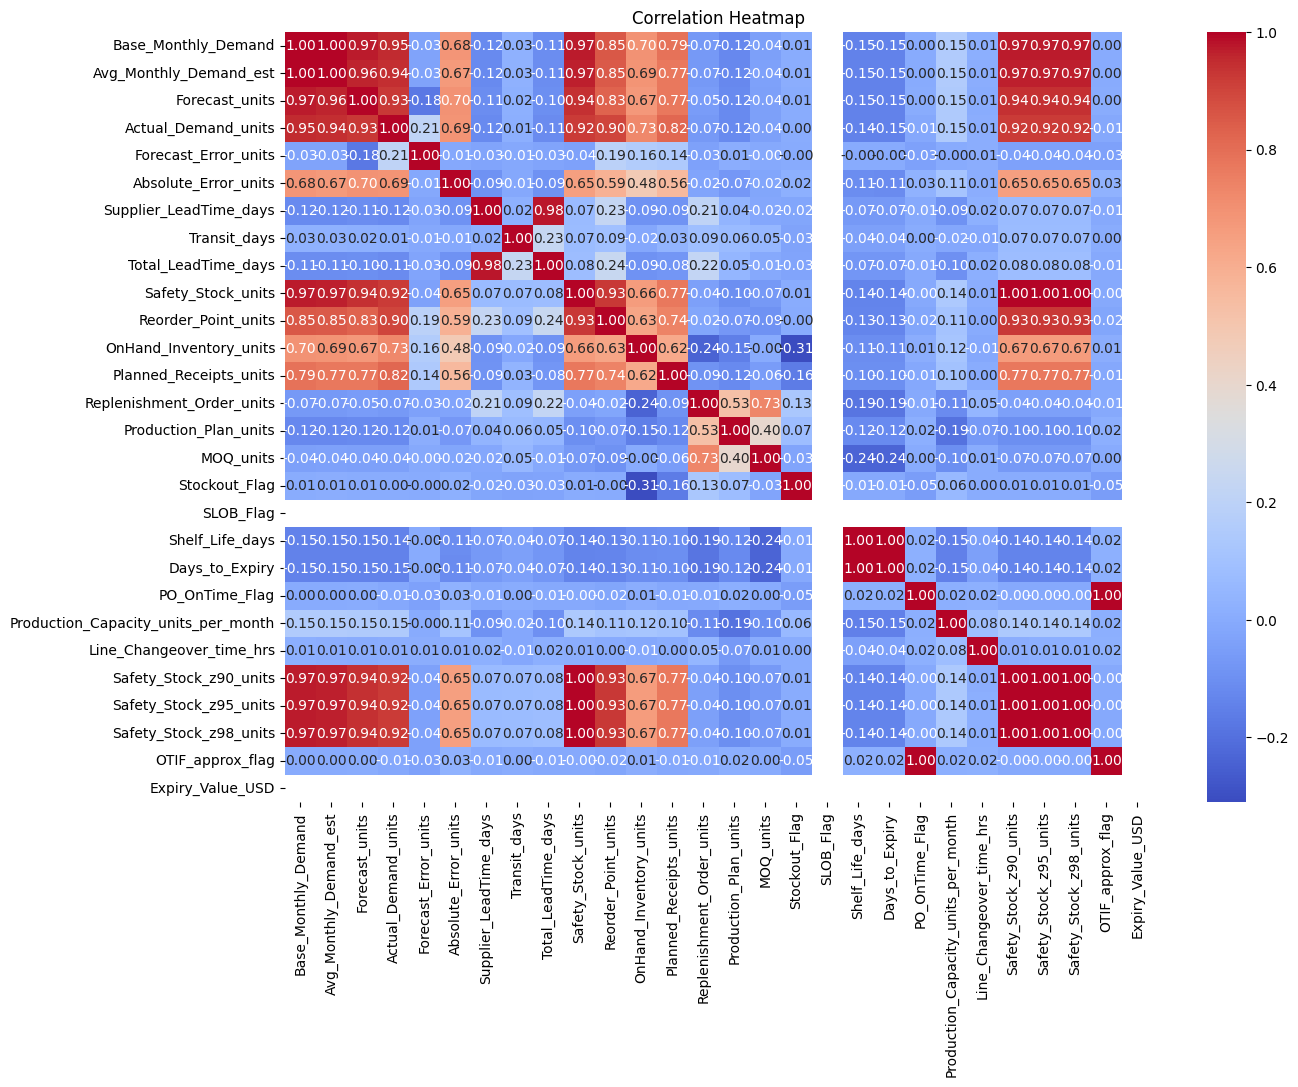

In [ ]:
# Correlation heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Correlation with target variable

target_corr = correlation["Shelf_Life_days"].sort_values(ascending=False)

print(target_corr)

Shelf_Life_days                        1.000000
Days_to_Expiry                         0.999956
OTIF_approx_flag                       0.021595
PO_OnTime_Flag                         0.021595
Forecast_Error_units                  -0.000995
Stockout_Flag                         -0.006911
Transit_days                          -0.041017
Line_Changeover_time_hrs              -0.043716
Supplier_LeadTime_days                -0.067887
Total_LeadTime_days                   -0.074690
Planned_Receipts_units                -0.104372
OnHand_Inventory_units                -0.105702
Absolute_Error_units                  -0.110343
Production_Plan_units                 -0.116132
Reorder_Point_units                   -0.131679
Safety_Stock_z90_units                -0.139078
Safety_Stock_z95_units                -0.139302
Safety_Stock_z98_units                -0.139713
Safety_Stock_units                    -0.139893
Actual_Demand_units                   -0.144788
Avg_Monthly_Demand_est                -0

## Correlation Analysis

The correlation analysis shows the relationship between each numerical feature and the target variable **Shelf_Life_days**.

The feature **Days_to_Expiry (0.9999)** has the strongest positive correlation with the target variable, indicating that it is the most influential feature for predicting shelf life.

Most of the remaining features have a weak negative correlation with **Shelf_Life_days**. Features such as **MOQ_units (-0.2351)**, **Replenishment_Order_units (-0.1858)**, **Production_Capacity_units_per_month (-0.1463)**, and **Forecast_units (-0.1454)** show a relatively stronger negative relationship compared to other variables.

The columns **SLOB_Flag** and **Expiry_Value_USD** contain only missing values or constant values, resulting in **NaN** correlations.

Overall, **Days_to_Expiry** is the most important predictor for this supervised machine learning problem.

# 4. Feature engineering (e.g., dosage to volume ratio,temperature bands).


In [ ]:
# Create Total Lead Time

df["Total_LeadTime_days"] = df["Supplier_LeadTime_days"] + df["Transit_days"]


In [ ]:
# Calculate Forecast Error

df["Forecast_Error_units"] = df["Forecast_units"] - df["Actual_Demand_units"]

In [ ]:
# Calculate Absolute Forecast Error

df["Absolute_Error_units"] = abs(df["Forecast_Error_units"])

In [ ]:
# Create Shelf Life Category

df["Shelf_Life_Category"] = pd.cut(
    df["Shelf_Life_days"],
    bins=[0, 180, 365, 1000],
    labels=["Short", "Medium", "Long"]
)

In [ ]:
# Display newly created features

df[[
    "Supplier_LeadTime_days",
    "Transit_days",
    "Total_LeadTime_days",
    "Forecast_units",
    "Actual_Demand_units",
    "Forecast_Error_units",
    "Absolute_Error_units",
    "Shelf_Life_days",
    "Shelf_Life_Category"
]].head()

,Supplier_LeadTime_days,Transit_days,Total_LeadTime_days,Forecast_units,Actual_Demand_units,Forecast_Error_units,Absolute_Error_units,Shelf_Life_days,Shelf_Life_Category
0,29,6,35,501,200,301,301,730,Long
1,29,8,37,194,407,-213,213,730,Long
2,29,10,39,308,634,-326,326,730,Long
3,29,1,30,502,781,-279,279,730,Long
4,29,4,33,643,448,195,195,730,Long


# 5. Encode categorical variables.


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Select categorical columns

categorical_columns = [
    "Product_Group",
    "Manufacturing_Line",
    "Customer_Priority",
    "Produced_InHouse",
    "Forecast_Method"
]

In [ ]:
# Apply Label Encoding

label_encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

In [ ]:
# Display encoded columns

df[categorical_columns].head()

,Product_Group,Manufacturing_Line,Customer_Priority,Produced_InHouse,Forecast_Method
0,4,0,0,1,3
1,4,0,0,1,3
2,4,0,0,1,3
3,4,0,0,1,3
4,4,0,0,1,3


In [ ]:
# Check data types after encoding

df[categorical_columns].dtypes

Product_Group         int64
Manufacturing_Line    int64
Customer_Priority     int64
Produced_InHouse      int64
Forecast_Method       int64
dtype: object

# 6. Build a Linear Regression model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [ ]:
# Prepare features and target
X = df.drop(columns=[
    "Shelf_Life_days",
    "Days_to_Expiry",
    "Manufacturing_Date",
    "Expiry_Date"
])

y = df["Shelf_Life_days"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X.isnull().sum().sum()


np.int64(0)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Train the Linear Regression model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Make predictions

y_pred_linear = linear_model.predict(X_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

print("RMSE :", rmse)
print("R2 Score :", r2)

RMSE : 63.67027881472688
R2 Score : 0.9451881096179146


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_linear
})

comparison.head(10)


,Actual,Predicted
521,730,739.477308
737,365,515.125835
740,540,572.836335
660,365,386.989036
411,1095,1120.073379
678,1095,980.387528
626,365,384.514301
513,365,385.327885
859,365,424.818478
136,540,554.312550


# 7. Build and evaluate Random Forest Regressor.


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
y_pred_rf = random_forest.predict(X_test)

In [ ]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RMSE :", rmse_rf)
print("R2 Score :", r2_rf)

RMSE : 20.9706121751369
R2 Score : 0.9940540193111684


In [ ]:
comparison_rf = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf
})

comparison_rf.head(10)

,Actual,Predicted
521,730,726.35
737,365,375.80
740,540,540.15
660,365,370.40
411,1095,1095.00
678,1095,1080.40
626,365,375.95
513,365,366.75
859,365,370.25
136,540,534.90


# 8. Compare with Gradient Boosting model.


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
# Create Gradient Boosting model

gradient_boosting = GradientBoostingRegressor(random_state=42)

In [ ]:
# Train the model

gradient_boosting.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [ ]:
# Predict on test data

y_pred_gb = gradient_boosting.predict(X_test)

In [ ]:
# Evaluate the model

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("RMSE :", rmse_gb)
print("R2 Score :", r2_gb)

RMSE : 109.20516277838297
R2 Score : 0.8387544944382586


In [ ]:
# Compare actual and predicted values

comparison_gb = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_gb
})

comparison_gb.head(10)

,Actual,Predicted
521,730,656.247687
737,365,474.992182
740,540,619.684631
660,365,444.875306
411,1095,997.415534
678,1095,939.039574
626,365,458.794410
513,365,470.447220
859,365,488.583074
136,540,575.581717


In [ ]:
# Compare model performance

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [rmse, rmse_rf, rmse_gb],
    "R2 Score": [r2, r2_rf, r2_gb]
})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,63.670279,0.945188
1,Random Forest,20.970612,0.994054
2,Gradient Boosting,109.205163,0.838754


# 9. Perform hyperparameter tuning using GridSearchCV.


In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
# Define parameters to test

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [ ]:
# Create GridSearchCV object

grid_search = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [ ]:
# Find the best parameters

grid_search.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

In [ ]:
print("Best Cross Validation Score:")
print(grid_search.best_score_)

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
y_pred_best = best_model.predict(X_test)

In [ ]:
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("RMSE :", rmse_best)
print("R2 Score :", r2_best)